In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_twitter.csv")

df.head()

,id,label,tweet,clean_tweet
0,1,0,@user when a father is dysfunctional and is s...,father dysfunct selfish drag kid dysfunct run
1,2,0,@user @user thanks for #lyft credit i can't us...,thank lyft credit cant use caus dont offer whe...
2,3,0,bihday your majesty,bihday majesti
3,4,0,#model i love u take with u all the time in ...,model love u take u time ur
4,5,0,factsguide: society now #motivation,factsguid societi motiv


In [2]:
print(df.shape)
df.head()

(31930, 4)


,id,label,tweet,clean_tweet
0,1,0,@user when a father is dysfunctional and is s...,father dysfunct selfish drag kid dysfunct run
1,2,0,@user @user thanks for #lyft credit i can't us...,thank lyft credit cant use caus dont offer whe...
2,3,0,bihday your majesty,bihday majesti
3,4,0,#model i love u take with u all the time in ...,model love u take u time ur
4,5,0,factsguide: society now #motivation,factsguid societi motiv


In [3]:
print(df.columns)

Index(['id', 'label', 'tweet', 'clean_tweet'], dtype='object')


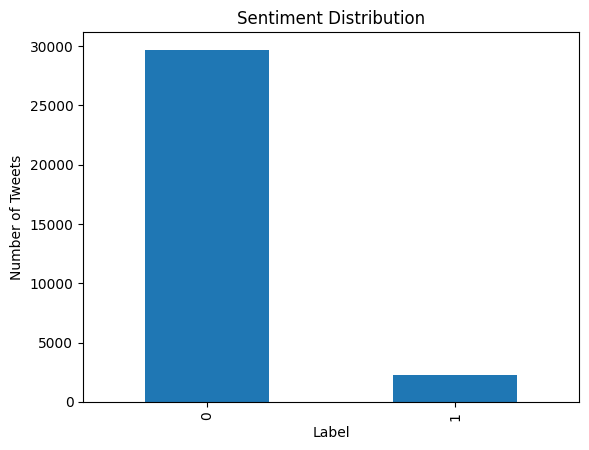

In [4]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Tweets")

plt.show()

In [5]:
df['label'].value_counts(normalize=True) * 100

label
0    92.987786
1     7.012214
Name: proportion, dtype: float64

### Top 20 Most Common Words


In [6]:
from collections import Counter

all_words = " ".join(df['clean_tweet'])

words = all_words.split()

common_words = Counter(words).most_common(20)

common_words

[('love', 3139),
 ('day', 2813),
 ('happi', 2084),
 ('amp', 1609),
 ('thank', 1542),
 ('get', 1257),
 ('time', 1237),
 ('im', 1157),
 ('u', 1148),
 ('go', 1145),
 ('life', 1143),
 ('like', 1114),
 ('today', 1086),
 ('posit', 991),
 ('new', 987),
 ('make', 980),
 ('father', 925),
 ('smile', 896),
 ('peopl', 886),
 ('bihday', 870)]

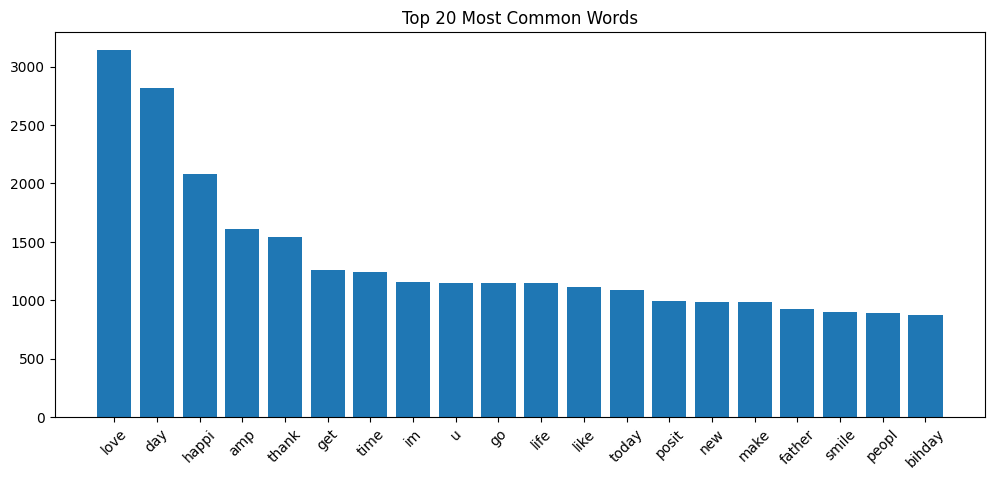

In [7]:
import matplotlib.pyplot as plt

words = [word for word, count in common_words]
counts = [count for word, count in common_words]

plt.figure(figsize=(12,5))
plt.bar(words, counts)

plt.xticks(rotation=45)
plt.title("Top 20 Most Common Words")
plt.show()

### Top Hate Speech Words

In [8]:
hate_df = df[df['label'] == 1]

all_hate_words = " ".join(hate_df['clean_tweet'])

from collections import Counter

hate_words = Counter(
    all_hate_words.split()
).most_common(20)

hate_words

[('amp', 283),
 ('trump', 216),
 ('white', 156),
 ('libtard', 150),
 ('black', 146),
 ('like', 144),
 ('racist', 109),
 ('polit', 101),
 ('peopl', 95),
 ('liber', 93),
 ('allahsoil', 92),
 ('hate', 86),
 ('obama', 81),
 ('say', 78),
 ('women', 78),
 ('might', 77),
 ('sjw', 75),
 ('new', 71),
 ('retweet', 68),
 ('dont', 67)]

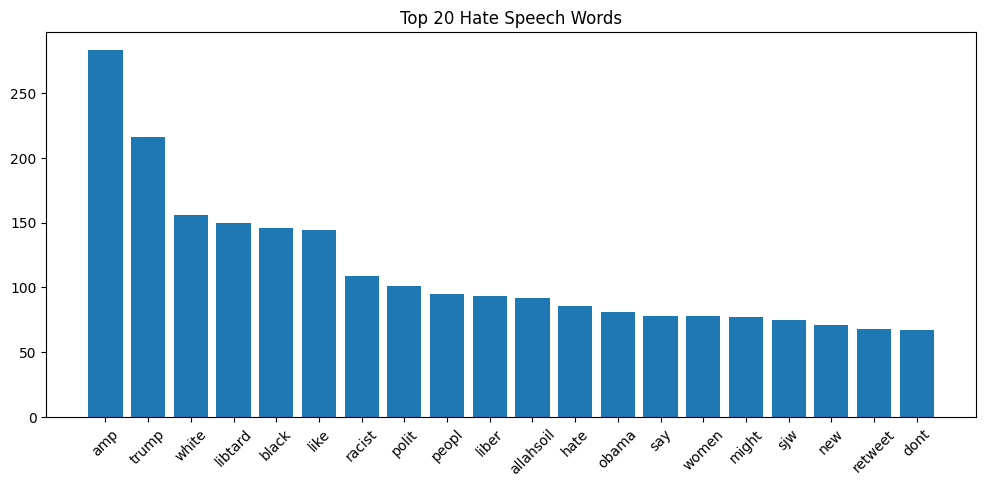

In [9]:
words = [word for word, count in hate_words]
counts = [count for word, count in hate_words]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.bar(words, counts)

plt.xticks(rotation=45)

plt.title("Top 20 Hate Speech Words")

plt.show()

### Top Normal Tweet Words

In [10]:
normal_df = df[df['label'] == 0]

all_normal_words = " ".join(
    normal_df['clean_tweet']
)

from collections import Counter

normal_words = Counter(
    all_normal_words.split()
).most_common(20)

normal_words

[('love', 3104),
 ('day', 2797),
 ('happi', 2072),
 ('thank', 1499),
 ('amp', 1326),
 ('time', 1205),
 ('get', 1204),
 ('life', 1136),
 ('u', 1121),
 ('im', 1112),
 ('go', 1100),
 ('today', 1069),
 ('posit', 987),
 ('like', 970),
 ('make', 939),
 ('father', 919),
 ('new', 916),
 ('smile', 894),
 ('bihday', 870),
 ('see', 837)]

### Overall Word Cloud

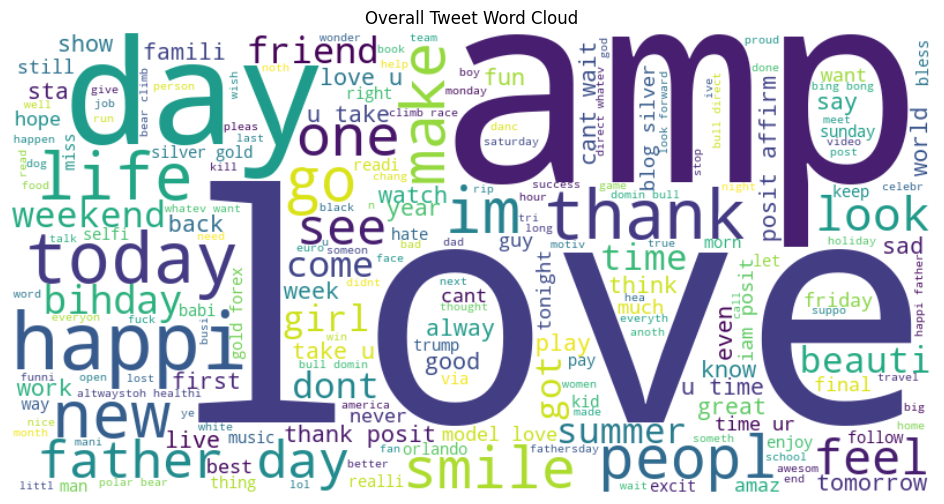

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['clean_tweet'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Overall Tweet Word Cloud")
plt.show()

### Hate Speech Word Cloud

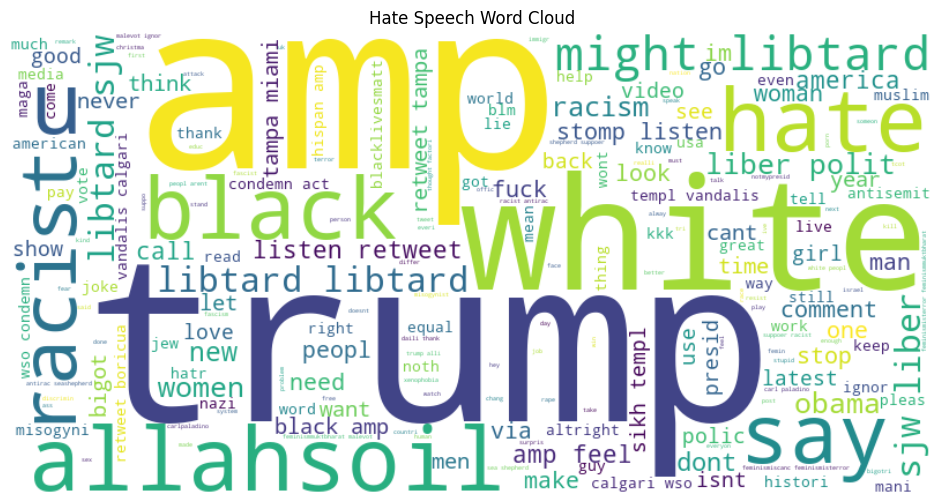

In [12]:
text = " ".join(hate_df['clean_tweet'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Hate Speech Word Cloud")
plt.show()

### Normal Tweet Word Cloud

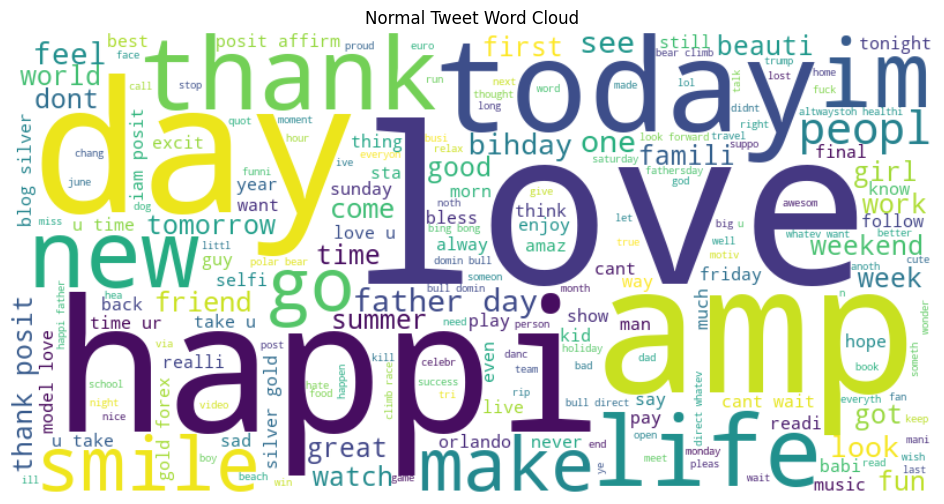

In [13]:
text = " ".join(normal_df['clean_tweet'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Normal Tweet Word Cloud")
plt.show()